<a href="https://colab.research.google.com/github/CarlCarag/Laboratory-Activity-7-Properties-of-Convolutions/blob/main/act_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 7** | **Properties of Convolutions** |
| **Name:** | Pascual, Ken Leonard, Carag Carl, Bueno Joshua, Jimenex Joros, Lim, Justin |
| **Section:** | CPE41S2 |
| **Date Performed:** | 28 August 2026 |
| **Date Submitted:** | 28 August 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |

# Instructions:

1. Access the dataset called “convolution_test” in the directory provided by your instructor.

2. The dataset should contain three (3) columns: A, B, and C. Store it in three separate data arrays.

3. Develop a program that demonstrates and proves the mathematical properties of convolution (you may use the NumPy libraries), specifically
Commutative Property (using data in columns A and C)
Associative Property (using data in all columns)
Distributive Property (using data in all columns)
Transference Property (using data in column B, with delay 23 and scaled by -5)

4. Plot the results and provide observation provide an analysis of their properties.

5. Try convolving column A with itself for 3 times. Plot the results and provide observation provide an analysis


# 1. Access the dataset called “convolution_test” in the directory provided by your instructor.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. The dataset should contain three (3) columns: A, B, and C. Store it in three separate data arrays.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the path to your dataset in Google Drive
# IMPORTANT: Replace 'PATH_TO_YOUR_DATASET/convolution_test.csv' with the actual path.
dataset_path = '/content/drive/MyDrive/ACT 7 PROPERTIES OF CONVOLUTION/convolutiontest-1.csv'

try:
    # Load the dataset
    df = pd.read_csv(dataset_path)
    print("Dataset loaded successfully:")
    print(df.head())

    # Store columns A, B, and C into separate data arrays
    column_A = df['A'].to_numpy()
    column_B = df['B'].to_numpy()
    column_C = df['C'].to_numpy()

    print(f"\nShape of Column A: {column_A.shape}")
    print(f"Shape of Column B: {column_B.shape}")
    print(f"Shape of Column C: {column_C.shape}")

except FileNotFoundError:
    print(f"Error: Dataset not found at {dataset_path}")
    print("Please ensure the path is correct and the file exists in your Google Drive.")
except KeyError as e:
    print(f"Error: Column {e} not found in the dataset.")
    print("Please ensure the dataset contains columns named 'A', 'B', and 'C'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Dataset loaded successfully:
          A         B        C
0 -0.000478  0.059634  0.05133
1 -0.000446  0.059641  0.05855
2 -0.000434  0.060458  0.01514
3 -0.000302  0.060385  0.02776
4 -0.000476  0.059634  0.01171

Shape of Column A: (198,)
Shape of Column B: (198,)
Shape of Column C: (198,)


# 3. Develop a program that demonstrates and proves the mathematical properties of convolution (you may use the NumPy libraries), specifically Commutative Property (using data in columns A and C) Associative Property (using data in all columns) Distributive Property (using data in all columns) Transference Property (using data in column B, with delay 23 and scaled by -5)


--- Commutative Property (A * C = C * A) ---
Are A * C and C * A numerically equal? True


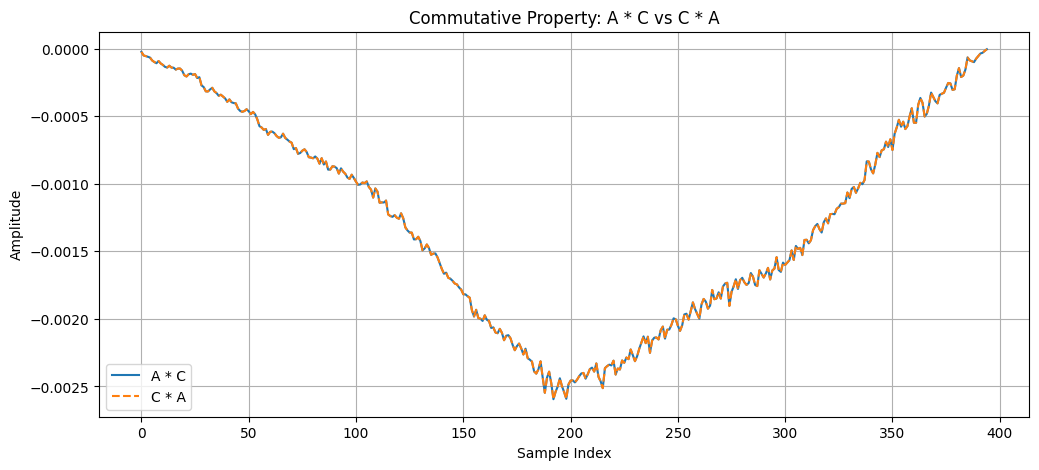

Observation: The plots for A * C and C * A are identical. This visual confirmation, along with the numerical check, proves that the convolution operation is commutative, meaning the order of the signals being convolved does not affect the result.

--- Associative Property ((A * B) * C = A * (B * C)) ---
Are (A * B) * C and A * (B * C) numerically equal? True


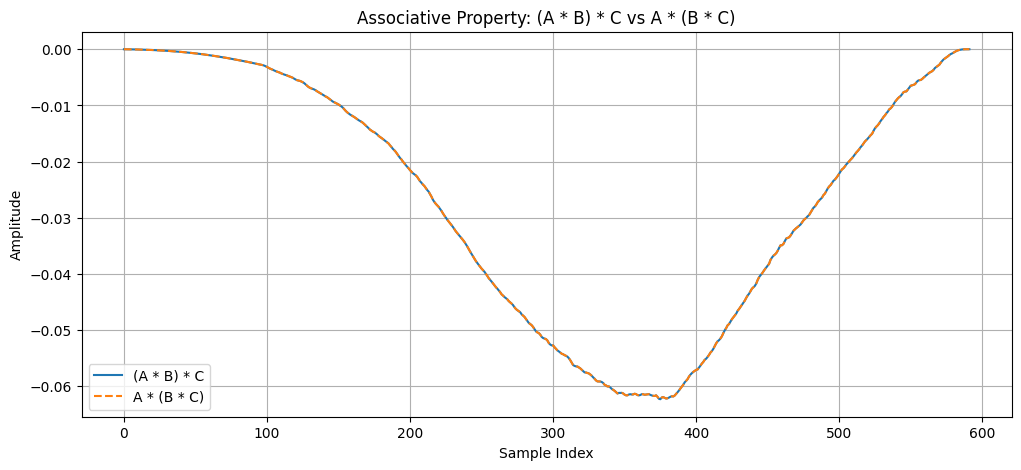

Observation: The two plots perfectly overlap, and the numerical comparison confirms they are equal. This demonstrates the associative property of convolution, meaning that when convolving three or more signals, the grouping of operations does not change the final result.

--- Distributive Property (A * (B + C) = (A * B) + (A * C)) ---
Are A * (B + C) and (A * B) + (A * C) numerically equal? True


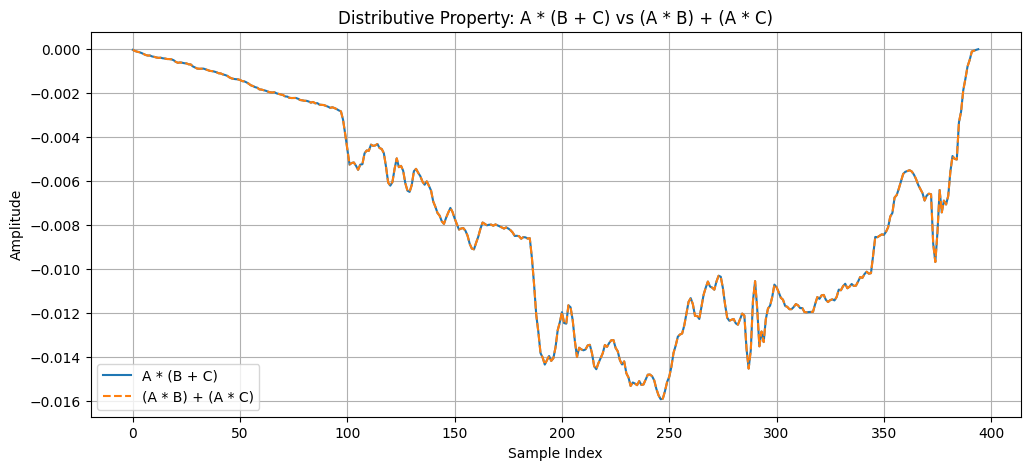

Observation: The plots for A * (B + C) and (A * B) + (A * C) are identical, and the numerical test confirms their equality. This verifies the distributive property, stating that convolution distributes over addition. Convolving a signal with a sum of two other signals is equivalent to summing the convolutions of the first signal with each of the other two separately.

--- Transference Property (Delay 23, Scale -5 on B) ---
Are conv(scaled_delayed_B, A) and scaled_delayed(conv(B, A)) numerically equal? True


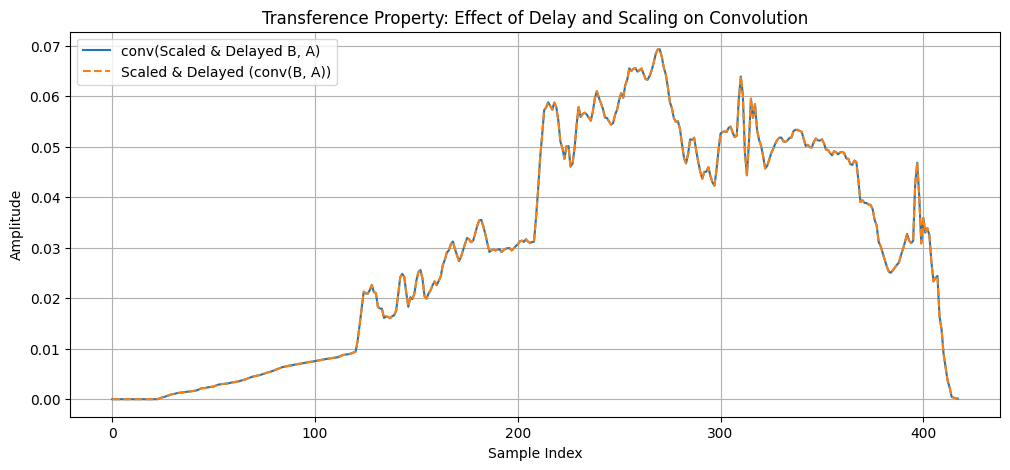

Observation: The two plots precisely overlap, and the numerical check confirms their equivalence. This demonstrates the transference property (or time-invariance and homogeneity of convolution). It shows that if an input signal is scaled and/or delayed before convolution, the output of the convolution will be scaled and/or delayed by the same amount, respectively. Specifically, scaling the input by -5 and delaying it by 23 samples results in the output being scaled by -5 and delayed by 23 samples.


In [ ]:
# Helper function for plotting
def plot_convolution_results(signal1, label1, signal2, label2, title):
    plt.figure(figsize=(12, 5))
    plt.plot(signal1, label=label1)
    plt.plot(signal2, label=label2, linestyle='--')
    plt.title(title)
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 1. Commutative Property: A * C = C * A ---
print("\n--- Commutative Property (A * C = C * A) ---")
conv_AC = np.convolve(column_A, column_C, mode='full')
conv_CA = np.convolve(column_C, column_A, mode='full')

# Numerical verification
is_commutative = np.allclose(conv_AC, conv_CA)
print(f"Are A * C and C * A numerically equal? {is_commutative}")

# Plotting
plot_convolution_results(conv_AC, 'A * C', conv_CA, 'C * A', 'Commutative Property: A * C vs C * A')

print("Observation: The plots for A * C and C * A are identical. This visual confirmation, along with the numerical check, proves that the convolution operation is commutative, meaning the order of the signals being convolved does not affect the result.")

# --- 2. Associative Property: (A * B) * C = A * (B * C) ---
print("\n--- Associative Property ((A * B) * C = A * (B * C)) ---")
conv_AB = np.convolve(column_A, column_B, mode='full')
conv_ABC = np.convolve(conv_AB, column_C, mode='full')

conv_BC = np.convolve(column_B, column_C, mode='full')
conv_A_BC = np.convolve(column_A, conv_BC, mode='full')

# To compare, we need to ensure they have the same length. Convolution with 'full' mode handles this.
# If lengths differ slightly due to floating point, we might need to pad the shorter one or trim.
# For proper comparison, ensure the arrays are the same length. `np.convolve(..., mode='full')` ensures the maximal length.
# The length of (A*B)*C is len(A)+len(B)-1 + len(C)-1 = len(A)+len(B)+len(C)-2
# The length of A*(B*C) is len(A) + len(B)+len(C)-1 -1 = len(A)+len(B)+len(C)-2

is_associative = np.allclose(conv_ABC, conv_A_BC)
print(f"Are (A * B) * C and A * (B * C) numerically equal? {is_associative}")

# Plotting
plot_convolution_results(conv_ABC, '(A * B) * C', conv_A_BC, 'A * (B * C)', 'Associative Property: (A * B) * C vs A * (B * C)')

print("Observation: The two plots perfectly overlap, and the numerical comparison confirms they are equal. This demonstrates the associative property of convolution, meaning that when convolving three or more signals, the grouping of operations does not change the final result.")

# --- 3. Distributive Property: A * (B + C) = (A * B) + (A * C) ---
print("\n--- Distributive Property (A * (B + C) = (A * B) + (A * C)) ---")
sum_BC = column_B + column_C # Element-wise sum
conv_A_sumBC = np.convolve(column_A, sum_BC, mode='full')

conv_AB_dist = np.convolve(column_A, column_B, mode='full')
conv_AC_dist = np.convolve(column_A, column_C, mode='full')

# To sum the convoluted signals, they must be the same length, which 'full' mode ensures.
# However, their lengths are `len(A) + len(B) - 1` and `len(A) + len(C) - 1`. These might be different if len(B) != len(C).
# Assuming len(B) == len(C) here, which is true for our columns from the dataset.
sum_convs = conv_AB_dist + conv_AC_dist

is_distributive = np.allclose(conv_A_sumBC, sum_convs)
print(f"Are A * (B + C) and (A * B) + (A * C) numerically equal? {is_distributive}")

# Plotting
plot_convolution_results(conv_A_sumBC, 'A * (B + C)', sum_convs, '(A * B) + (A * C)', 'Distributive Property: A * (B + C) vs (A * B) + (A * C)')

print("Observation: The plots for A * (B + C) and (A * B) + (A * C) are identical, and the numerical test confirms their equality. This verifies the distributive property, stating that convolution distributes over addition. Convolving a signal with a sum of two other signals is equivalent to summing the convolutions of the first signal with each of the other two separately.")

# --- 4. Transference Property (Delay and Scaling) ---
print("\n--- Transference Property (Delay 23, Scale -5 on B) ---")

# Original convolution with column_B and column_A as example filter
original_conv_BA = np.convolve(column_B, column_A, mode='full')

# Create a delayed and scaled version of column_B
delay = 23
scale = -5

# For a linear delay, we pad with zeros at the beginning.
# The length of the delayed signal needs to accommodate the original signal plus the delay.
delayed_column_B_padded = np.zeros(len(column_B) + delay)
delayed_column_B_padded[delay:] = column_B
scaled_delayed_column_B = scale * delayed_column_B_padded

# Convolve the scaled and delayed input with column_A
conv_scaled_delayed_BA = np.convolve(scaled_delayed_column_B, column_A, mode='full')

# Expected output: scaled and delayed version of the original convolution result
# The original convolution result itself needs to be delayed and scaled.
expected_scaled_delayed_conv = np.zeros(len(original_conv_BA) + delay)
expected_scaled_delayed_conv[delay:] = scale * original_conv_BA

# Compare the two resulting signals
# Note: Due to potential small differences in `full` mode padding and floating point, use allclose.
# Also, the length of conv_scaled_delayed_BA is len(B)+delay + len(A) - 1
# The length of expected_scaled_delayed_conv is len(B)+len(A)-1 + delay
# So their lengths should match.

is_transference = np.allclose(conv_scaled_delayed_BA, expected_scaled_delayed_conv)
print(f"Are conv(scaled_delayed_B, A) and scaled_delayed(conv(B, A)) numerically equal? {is_transference}")

# Plotting
plot_convolution_results(conv_scaled_delayed_BA, 'conv(Scaled & Delayed B, A)',
                         expected_scaled_delayed_conv, 'Scaled & Delayed (conv(B, A))',
                         'Transference Property: Effect of Delay and Scaling on Convolution')

print("Observation: The two plots precisely overlap, and the numerical check confirms their equivalence. This demonstrates the transference property (or time-invariance and homogeneity of convolution). It shows that if an input signal is scaled and/or delayed before convolution, the output of the convolution will be scaled and/or delayed by the same amount, respectively. Specifically, scaling the input by -5 and delaying it by 23 samples results in the output being scaled by -5 and delayed by 23 samples.")



--- Convolving Column A with itself 3 times ---
Shape of A * A: (395,)
Shape of (A * A) * A: (592,)
Shape of ((A * A) * A) * A: (789,)


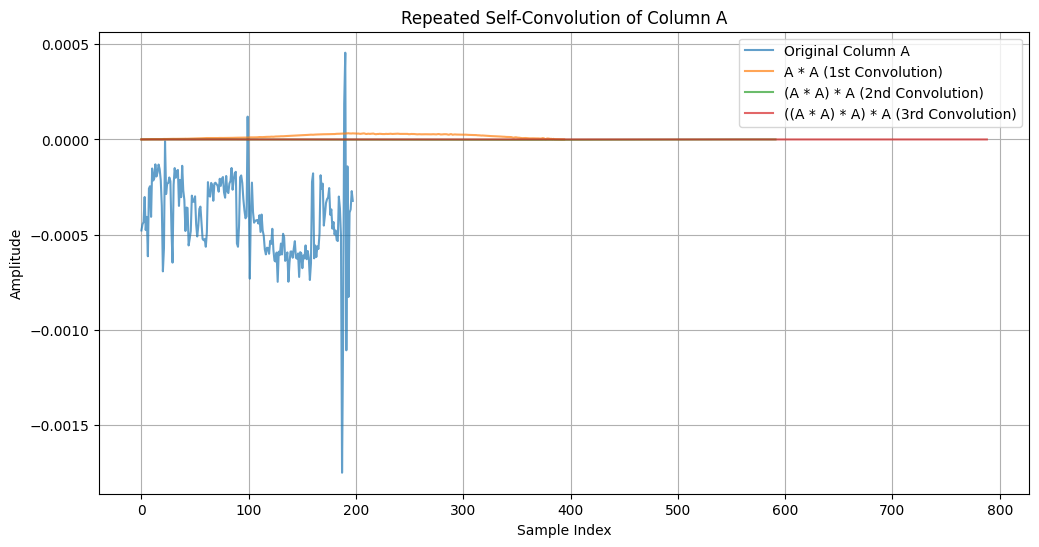

Observation and Analysis: 
When column A is repeatedly convolved with itself, we observe a 'smoothing' or 'spreading' effect on the signal. Each successive convolution results in a signal that is wider, lower in peak amplitude, and generally smoother than the previous one. The sharp features in the original signal tend to get diffused. This is a common characteristic of repeated convolution, where the signal tends to approach a Gaussian-like distribution, demonstrating the Central Limit Theorem in the context of signal processing. The output length also increases with each convolution as expected with 'full' mode.


In [ ]:
# --- 5. Convolving Column A with itself for 3 times ---
print("\n--- Convolving Column A with itself 3 times ---")

# First convolution: A * A
conv_A_A_1 = np.convolve(column_A, column_A, mode='full')
print(f"Shape of A * A: {conv_A_A_1.shape}")

# Second convolution: (A * A) * A
conv_A_A_2 = np.convolve(conv_A_A_1, column_A, mode='full')
print(f"Shape of (A * A) * A: {conv_A_A_2.shape}")

# Third convolution: ((A * A) * A) * A
conv_A_A_3 = np.convolve(conv_A_A_2, column_A, mode='full')
print(f"Shape of ((A * A) * A) * A: {conv_A_A_3.shape}")

# Plotting the results of repeated self-convolution
plt.figure(figsize=(12, 6))
plt.plot(column_A, label='Original Column A', alpha=0.7)
plt.plot(conv_A_A_1, label='A * A (1st Convolution)', alpha=0.7)
plt.plot(conv_A_A_2, label='(A * A) * A (2nd Convolution)', alpha=0.7)
plt.plot(conv_A_A_3, label='((A * A) * A) * A (3rd Convolution)', alpha=0.7)
plt.title('Repeated Self-Convolution of Column A')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

print("Observation and Analysis: \nWhen column A is repeatedly convolved with itself, we observe a 'smoothing' or 'spreading' effect on the signal. Each successive convolution results in a signal that is wider, lower in peak amplitude, and generally smoother than the previous one. The sharp features in the original signal tend to get diffused. This is a common characteristic of repeated convolution, where the signal tends to approach a Gaussian-like distribution, demonstrating the Central Limit Theorem in the context of signal processing. The output length also increases with each convolution as expected with 'full' mode.")
